# Basics of Data Flows

The `DataFlow` class provides a powerful tool for organizing and executing data processing tasks. In this tutorial, we will explore basic practical examples of how to leverage `DataFlow` instances to create and apply efficient, reusable workflows for handling diverse data processing tasks.

## Importing Required Libraries

To get started, we first need to import the required libraries and modules. These will provide the necessary tools for working with datasets and the `DataFlow` framework.

In [1]:
import datasets
from hyped import DataFlow, plot_data_flow

## Creating a Sample Dataset

Next, we'll create a simple dataset using the HuggingFace `datasets` library. This dataset includes a few sample features to work with, making it easy to understand how to build and apply data flows.

In [2]:
ds = datasets.Dataset.from_list(
    [
        {"i": 0, "x": [1, 2]},
        {"i": 1, "x": [2, 3]},
        {"i": 2, "x": [3, 4]},
        {"i": 3, "x": [4, 5]},
    ],
    features=datasets.Features(
        {
            "i": datasets.Value("int32"),
            "x": datasets.Sequence(datasets.Value("int64"))
        }
    )
)

## Initializing a `DataFlow` Instance

The simplest way to initialize a DataFlow instance is to use the dataset features.

In [3]:
flow = DataFlow(ds.features)

By providing the dataset's feature schema, we directly tie the `DataFlow` to the dataset, allowing seamless interaction with its data. This approach is ideal for straightforward use cases where the dataset schema is sufficient to define the flow.

## Understanding `flow.source`

The `source` property of a `DataFlow` instance provides access to the source features, which serve as the input data for your processing pipeline. This is a (potentially nested) object that reflects the structure of your input dataset.

**Key Characteristics**:

- It behaves like a Python dictionary, allowing you to access features by their names (keys).
- The source features are dynamically typed based on the dataset schema or the provided mapping class during initialization.

**Accessing Features**

To access specific input features, simply use dictionary-style indexing. For instance:

In [4]:
# Accessing the input feature 'i'
flow.source["i"]

Int32Feature(ref=ConcreteReference(_node_id='2416da6e-c212-cddb-8d88-00160eb686b2', _graph=<hyped.core.graph.DataFlowGraph object at 0x150b7fc50>))

If a feature is a sequence, you can further index into it:

In [5]:
# Accessing the first value in the sequence feature 'x'
flow.source["x"][0]  

Int64Feature(ref=ConcreteReference(_node_id='71445abc-2f0d-dac2-4097-acb7a3823bc9', _graph=<hyped.core.graph.DataFlowGraph object at 0x150b7fc50>))

This approach makes defining processing pipelines intuitive and Pythonic, as you work directly with the features as you would with a native Python object. In the next section, we’ll explore how to build processing pipelines using these source features.

## Building Processing Pipelines

Defining processing pipelines is as simple and intuitive as performing standard Python operations. You work directly with the `flow.source` features, applying computations and transformations to build the desired outputs.

Suppose you want to compute the sum of the values in the sequence feature `x` and multiply it by the scalar feature `i`. This can be done effortlessly with the following expression:

In [6]:
y = flow.source["i"] * flow.source["x"].sum()

Note that the result `y` is itself a feature, meaning it can be further processed or combined with other features and operations in the pipeline.

In [7]:
z = y * 2

Here, `z` is derived by multiplying the feature `y` with a constant value. This flexibility allows for easy integration of constants into your pipelines.

While using `DataFlow` is simple and Pythonic, it operates under the hood by building a directed graph of processing steps. Essentially, `DataFlow` constructs an **abstract syntax tree (AST)** of the processing pipeline, with nodes representing individual operations or transformations.

To gain insight into the inner workings of your pipeline, you can visualize the flow of data and the operations being performed at each step. This can be easily done using the following function:

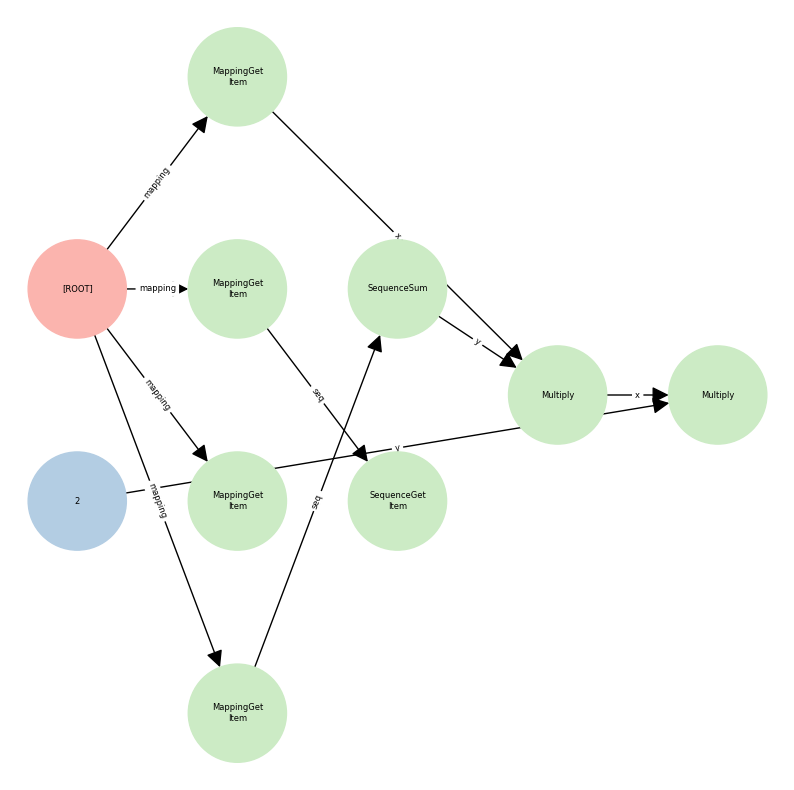

In [8]:
plot_data_flow(flow);

Note how all operations taken so far are represented by a separate node in the AST. This also includes indexing operations (e.g. `flow.source["i"]`).  

## Building the Data Flow

Up until now, we’ve been defining the processing pipeline and visualizing it, but no output has been explicitly defined. The next step is to build the data flow, where we specify the output and prepare the graph for execution. During this step, the data flow is optimized, and unnecessary computations are eliminated.

In the visualized graph, you may notice multiple "dead ends" or nodes that are not directly involved in the final output. The building process takes care of these redundancies and ensures that only the relevant parts of the graph are retained for computation.

To build the data flow, you can use the `build()` method and specify which parts of the pipeline should produce the output.

In [9]:
flow = flow.build(collect={"z": z})

The `collect` argument specifies the output features you want to retain, in this case, `z`. The `build()` function will optimize the graph and include only the necessary nodes required to compute `z`. This can be seen when visualizing the build flow.

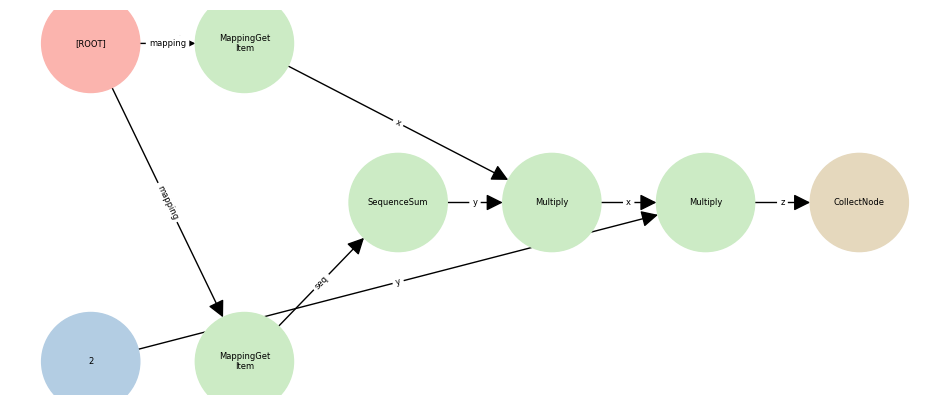

In [10]:
plot_data_flow(flow);

### Applying the Data Flow

Once the data flow has been defined and built, and the output has been specified, the final step is to apply the data flow to a dataset. This is done by passing the dataset to the `apply()` method.

In [11]:
out_ds = flow.apply(ds)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

This step processes the input dataset `ds` according to the defined pipeline and produces the output dataset `out_ds`.

Note that the features of `out_ds` align with the `collect` argument.

In [12]:
out_ds.to_dict()

{'z': [0, 10, 28, 54]}

## Conclusion

In this tutorial, we've walked through how to define and build data processing pipelines using the `DataFlow` framework. From initializing the data flow and working with features to optimizing the computation graph and applying the flow to a dataset, each step allows you to easily transform and process data in a clean and efficient way.

To recap, the entire process boils down to just a few lines of code:

In [13]:
flow = DataFlow(ds.features)
flow = flow.build(collect={"z": 2 * (flow.source["i"] * flow.source["x"].sum())})
out_ds = flow.apply(ds)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

This approach simplifies complex workflows, making it possible to define, optimize, and execute data transformations efficiently. With just a few steps, you can go from raw data to the processed output, all while ensuring that your pipeline is both scalable and easily maintainable.